In [16]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

import glob, pyBigWig, shutil, os
import pandas as pd

import sys
sys.path.append('esvar/')
from esvar import esvar

### Bcell_GO_0035456 genetic

In [2]:
genetic  = "/project/Wellcome_Discovery/sriva/Git/ESVAR/genetics_test/Bcell_GO_0035456.tsv"
es       = esvar(genetic=genetic, output="Heatmap", collection_name="super_pbmc")
df_esvar = es.calculate_enrichment_score(less100=False, greater25k=False)
df_cover = es.get_coverage()

Removing NaN rows from loaded file ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:03<00:00,  6.16it/s]


Intersecting genetic with peak regions ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:07<00:00,  2.62it/s]


For each fold, parallelised shuffling background ...
Calculating (1) total number of base-pairs within peaks and (2) total number of base-pairs within peaks divided by uniquely mappable base-pairs ...


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:39<00:00,  7.98s/it]


Calculating statistics ...
Adding shuffled background ...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:34<00:00,  6.87s/it]


Calculating statistics ...
Cleaning temporary files ...
Processing genetics finished.
Removing NaN rows from loaded file ...
Getting coverage ...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:19<00:00,  1.04s/it]


In [15]:
help(es)

Help on esvar in module esvar.esvar object:

class esvar(builtins.object)
 |  esvar(genetic=None, number_of_folds=5, output='output', genome='hg38', seed=42, collection_name='', in_house_collection_path='')
 |  
 |  Methods defined here:
 |  
 |  __init__(self, genetic=None, number_of_folds=5, output='output', genome='hg38', seed=42, collection_name='', in_house_collection_path='')
 |      __init__.
 |      
 |      Parameters
 |      ----------
 |      genetic : str
 |              Path to genetic file.
 |      number_of_folds : integer
 |              Number of folds to create backgound using the 1000genomes.
 |      output : str
 |              Directory where to save the scores.
 |      genome : str
 |              Genome to use, available 'hg19' and 'hg38'.
 |      seed : int
 |              Seed for reproducibility, shuffle 1000genomes excluded.
 |      collection_name : str
 |              Data collection name, available 'cad', 'calderon', 'catlas_fetal', 'catlas_adult', 'erytho

### Heatmap plots

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
rounds = sorted(glob.glob("Heatmap/rounds/statistics_intermediate_round*"))
esvar  = sorted(glob.glob("Heatmap/statistics_ESVAR.csv"))

In [5]:
rounds

['heatmap/rounds/statistics_intermediate_round1.csv',
 'heatmap/rounds/statistics_intermediate_round2.csv',
 'heatmap/rounds/statistics_intermediate_round3.csv',
 'heatmap/rounds/statistics_intermediate_round4.csv',
 'heatmap/rounds/statistics_intermediate_round5.csv']

In [6]:
esvar

['heatmap/statistics_ESVAR.csv']

In [7]:
dfs = []
for r in rounds:
    df = pd.read_csv(r, sep='\t', index_col=0)
    df = df[['ESVAR']]
    name = r.split("/")[-1].replace(".csv", "")
    df.index = df.index + "_%s"%name
    dfs.append(df)
    
df = pd.concat(dfs)

print('min value:    ', df['ESVAR'].min())
print('mean value:   ', df['ESVAR'].mean())
print('median value: ', df['ESVAR'].median())
print('max value:    ', df['ESVAR'].max())

min value:     1.2075906839119368
mean value:    9.022096288219826
median value:  6.02798119170806
max value:     35.724177322922145


In [9]:
vmax = 0
for df in dfs:
    if df['ESVAR'].max() > vmax:
        vmax = df['ESVAR'].max()

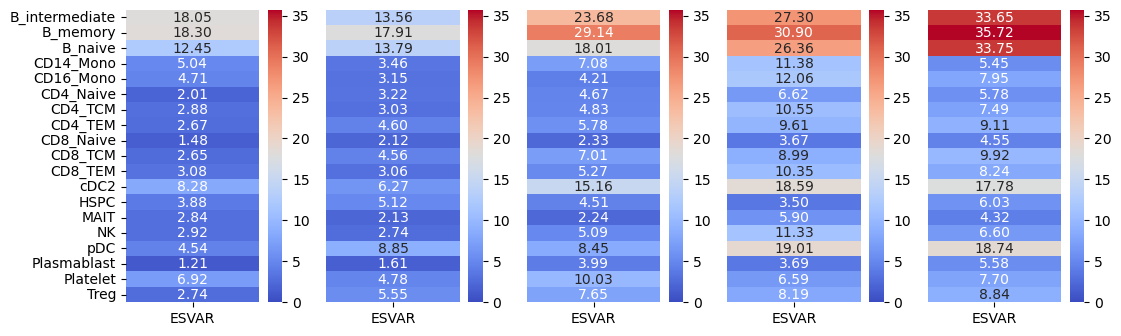

In [10]:
f, ax = plt.subplots(1,len(dfs),figsize=(len(dfs)*2.5,dfs[0].shape[0]/5))
for i, df in enumerate(dfs):
    if i == 0:
        df.index = df.index.str.replace("_statistics_intermediate_round1", "")
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], fmt='.2f', cmap='coolwarm', vmin=0, vmax=vmax)
    else:
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], yticklabels=False, fmt='.2f', cmap='coolwarm', vmin=0, vmax=vmax)
plt.show()

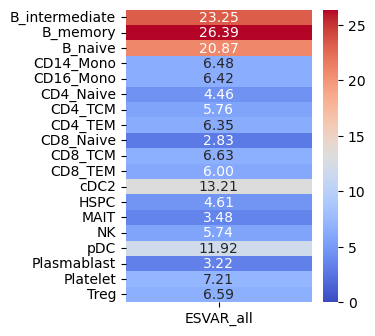

In [11]:
df = pd.read_csv(esvar[0], sep='\t', index_col=0)
f, ax = plt.subplots(1,1,figsize=(3,df.shape[0]/5))
ax = sns.heatmap(df, annot=True, ax=ax, fmt='.2f', cmap='coolwarm', vmin=0)
plt.show()